In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
import copy
import gif
from IPython.display import Image
import random

In [2]:
def animate(data, j, patch, head, joints):
    first = []
    second = []
    for i in joints:
        first.append(data[j][0][i])
        second.append(data[j][1][i])
    a = np.array([first, second])
    a = np.transpose(a)
    patch.set_xy(a)
    head.center = (data[j][0][5], data[j][1][5])
    return patch, head

# To create a gif image
@gif.frame
def plot_samples_normal(data, j):
    # draw the simulation
    fig = plt.figure()
    fig.set_dpi(100)
    fig.set_size_inches(12, 3)

    ax = plt.axes(xlim=(-1, 10), ylim=(-0.1, 3))


    joints = [5, 0, 1, 2, 1, 0, 3, 4]
    patch = plt.Polygon([[0, 0], [0, 0]], closed=None, fill=None, edgecolor="k")
    head = plt.Circle((0, 0), radius=0.15, fc="k", ec="k")
    ax.add_patch(patch)
    ax.add_patch(head)
    plt.title(f"total_distance: {data[j][0][5]:.2f}")
    animate(data, j, patch, head, joints)
    # ax.Line2D([-0.5, 0], [10, 0], color='black')

    step_size = 11 / len(data)

    # Add a progress bar rectangle at the bottom
    progress_bar_height = 0.1
    progress_bar_y = -0.1  # Position of the progress bar on the y-axis
    progress_bar = plt.Rectangle((-1, progress_bar_y), step_size*j, progress_bar_height, color='blue')
    ax.add_patch(progress_bar)

    # Add a border for the progress bar
    progress_bar_border = plt.Rectangle((-1, progress_bar_y), 11, progress_bar_height, fill=False, edgecolor='black', linewidth=1)
    ax.add_patch(progress_bar_border)



In [3]:
# plan is an array of 40 floating point numbers
def sim(plan):
    """
    Simulates the motion of a multi-jointed body based on a given plan.

    Parameters:
    plan (list of float): A list of control parameters for the simulation. Each element should be between -1 and 1.

    Returns:
    tuple:
        - data (list of list of list of float): A list of positions of the body parts at each time step. Each position is a list of two lists, representing the x and y coordinates of the body parts.
        - final_position (float): The final x-coordinate of the head (body part 5).

    The simulation involves:
    - Adjusting the control parameters to be within the range [-1, 1].
    - Initializing physical properties such as mass, edge lengths, spring constants, and damping factors.
    - Iteratively updating the positions and velocities of the body parts based on forces, torques, and constraints.
    - Handling contact with the ground and applying friction.
    - Recording the positions of the body parts at each time step.
    - Returning the recorded data and the final x-coordinate of the head.
    """
    for i in range(0, len(plan)):
        if plan[i] > 1:
            plan[i] = 1.0
        elif plan[i] < -1:
            plan[i] = -1.0

    dt = 0.1 # time step
    friction = 1.0 # friction coefficient
    gravity = 0.1 # gravity constant
    mass = [30, 10, 5, 10, 5, 10] # mass of body parts
    edgel = [0.5, 0.5, 0.5, 0.5, 0.9] # edge lengths
    edgesp = [160.0, 180.0, 160.0, 180.0, 160.0]    # spring constants
    edgef = [8.0, 8.0, 8.0, 8.0, 8.0]   # damping factors
    anglessp = [20.0, 20.0, 10.0, 10.0] # angular spring constants
    anglesf = [8.0, 8.0, 4.0, 4.0]  # angular damping factors

    edge = [(0, 1), (1, 2), (0, 3), (3, 4), (0, 5)] # edges
    angles = [(4, 0), (4, 2), (0, 1), (2, 3)] # angles

    # vel and pos of the body parts, 0 is hip, 5 is head, others are joints
    v = [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
    p = [[0, 0, -0.25, 0.25, 0.25, 0.15], [1, 0.5, 0, 0.5, 0, 1.9]]

    spin = 0.0
    maxspin = 0.0
    lastang = 0.0

    data = []

    for j in range(20): # 20 time steps
        for k in range(10): # 10 substeps
            lamb = 0.05 + 0.1 * k 
            t0 = 0.5
            if j > 0:
                t0 = plan[2 * j - 2]
            t0 *= 1 - lamb
            t0 += plan[2 * j] * lamb

            t1 = 0.0
            if j > 0:
                t1 = plan[2 * j - 1]
            t1 *= 1 - lamb
            t1 += plan[2 * j + 1] * lamb

            contact = [False, False, False, False, False, False]
            for z in range(6):
                if p[1][z] <= 0:
                    contact[z] = True
                    spin = 0
                    p[1][z] = 0

            anglesl = [-(2.8 + t0), -(2.8 - t0), -(1 - t1) * 0.9, -(1 + t1) * 0.9] 

            disp = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
            dist = [0, 0, 0, 0, 0]
            dispn = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
            for z in range(5):
                disp[0][z] = p[0][edge[z][1]] - p[0][edge[z][0]]
                disp[1][z] = p[1][edge[z][1]] - p[1][edge[z][0]]
                dist[z] = (
                    math.sqrt(disp[0][z] * disp[0][z] + disp[1][z] * disp[1][z]) + 0.01
                )
                inv = 1.0 / dist[z]
                dispn[0][z] = disp[0][z] * inv
                dispn[1][z] = disp[1][z] * inv 

            dispv = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
            distv = [0, 0, 0, 0, 0]
            for z in range(5):
                dispv[0][z] = v[0][edge[z][1]] - v[0][edge[z][0]]
                dispv[1][z] = v[1][edge[z][1]] - v[1][edge[z][0]]
                distv[z] = 2 * (disp[0][z] * dispv[0][z] + disp[1][z] * dispv[1][z])

            forceedge = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
            for z in range(5):
                c = (edgel[z] - dist[z]) * edgesp[z] - distv[z] * edgef[z]
                forceedge[0][z] = c * dispn[0][z]
                forceedge[1][z] = c * dispn[1][z]

            edgeang = [0, 0, 0, 0, 0]
            edgeangv = [0, 0, 0, 0, 0]
            for z in range(5):
                edgeang[z] = math.atan2(disp[1][z], disp[0][z])
                edgeangv[z] = (dispv[0][z] * disp[1][z] - dispv[1][z] * disp[0][z]) / (
                    dist[z] * dist[z]
                )

            inc = edgeang[4] - lastang
            if inc < -math.pi:
                inc += 2.0 * math.pi
            elif inc > math.pi:
                inc -= 2.0 * math.pi
            spin += inc
            spinc = spin - 0.005 * (k + 10 * j)
            if spinc > maxspin:
                maxspin = spinc
                lastang = edgeang[4]

            angv = [0, 0, 0, 0]
            for z in range(4): 
                angv[z] = edgeangv[angles[z][1]] - edgeangv[angles[z][0]]

            angf = [0, 0, 0, 0]
            for z in range(4):
                ang = edgeang[angles[z][1]] - edgeang[angles[z][0]] - anglesl[z]
                if ang > math.pi:
                    ang -= 2 * math.pi
                elif ang < -math.pi:
                    ang += 2 * math.pi
                m0 = dist[angles[z][0]] / edgel[angles[z][0]]
                m1 = dist[angles[z][1]] / edgel[angles[z][1]]
                angf[z] = ang * anglessp[z] - angv[z] * anglesf[z] * min(m0, m1)

            edgetorque = [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
            for z in range(5):
                inv = 1.0 / (dist[z] * dist[z])
                edgetorque[0][z] = -disp[1][z] * inv
                edgetorque[1][z] = disp[0][z] * inv

            for z in range(4):
                i0 = angles[z][0]
                i1 = angles[z][1]
                forceedge[0][i0] += angf[z] * edgetorque[0][i0]
                forceedge[1][i0] += angf[z] * edgetorque[1][i0]
                forceedge[0][i1] -= angf[z] * edgetorque[0][i1]
                forceedge[1][i1] -= angf[z] * edgetorque[1][i1]

            f = [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]]
            for z in range(5):
                i0 = edge[z][0]
                i1 = edge[z][1]
                f[0][i0] -= forceedge[0][z]
                f[1][i0] -= forceedge[1][z]
                f[0][i1] += forceedge[0][z]
                f[1][i1] += forceedge[1][z]

            for z in range(6):
                f[1][z] -= gravity * mass[z]
                invm = 1.0 / mass[z]
                v[0][z] += f[0][z] * dt * invm
                v[1][z] += f[1][z] * dt * invm

                if contact[z]:
                    fric = 0.0
                    if v[1][z] < 0.0:
                        fric = -v[1][z]
                        v[1][z] = 0.0

                    s = np.sign(v[0][z])
                    if v[0][z] * s < fric * friction:
                        v[0][z] = 0
                    else:
                        v[0][z] -= fric * friction * s
                p[0][z] += v[0][z] * dt
                p[1][z] += v[1][z] * dt

            data.append(copy.deepcopy(p))

            if contact[0] or contact[5]:
                return data, p[0][5]
    return data, p[0][5]

In [4]:
#Simulatied Annealing
def optimize_simulated_annealing(sim, initial_plan, max_iterations=500, initial_temperature=1.0, cooling_rate=0.99):
    def clamp(value):
        return max(-1, min(1, value))

    current_plan = [clamp(x) for x in initial_plan]
    _, current_distance = sim(current_plan)
    best_plan = current_plan[:]
    best_distance = current_distance
    temperature = initial_temperature

    for iteration in range(max_iterations):
        # Generate a new plan with small random perturbations
        new_plan = current_plan[:]
        for i in range(len(new_plan)):
            new_plan[i] += random.uniform(-0.1, 0.1) * temperature
            new_plan[i] = clamp(new_plan[i])

        # Simulate the new plan
        try:
            _, new_distance = sim(new_plan)
        except Exception as e:
            print(f"Simulation error at iteration {iteration}: {e}")
            continue

        # Debug output for the new plan and distance
        print(f"Iteration {iteration}: New Distance = {new_distance}, Best Distance = {best_distance}")

        # Decide whether to accept the new plan
        delta = new_distance - current_distance
        acceptance_probability = min(1, math.exp(delta / temperature)) if delta < 0 else 1
        if random.random() < acceptance_probability:
            current_plan = new_plan
            current_distance = new_distance

            # Update the best plan if the new plan is better
            if current_distance > best_distance:
                best_plan = current_plan
                best_distance = current_distance

        # Cool down the temperature
        temperature *= cooling_rate

        # Debugging output every 50 iterations
        if iteration % 50 == 0:
            print(f"Iteration {iteration}: Best Distance = {best_distance:.2f}")

    return best_plan, best_distance


In [5]:
# Initialize a random plan
initial_plan = [random.uniform(-1, 1) for _ in range(40)]

# Optimize using Simulated Annealing
best_plan_sa, best_distance_sa = optimize_simulated_annealing(sim, initial_plan)
print("Simulated Annealing - Best Plan:", best_plan_sa)
print("Simulated Annealing - Best Distance:", best_distance_sa)

Iteration 0: New Distance = -0.6960590351062458, Best Distance = -0.9185594854561898
Iteration 0: Best Distance = -0.70
Iteration 1: New Distance = -0.9092232964761855, Best Distance = -0.6960590351062458
Iteration 2: New Distance = -0.654192776141514, Best Distance = -0.6960590351062458
Iteration 3: New Distance = -0.6239171763314008, Best Distance = -0.654192776141514
Iteration 4: New Distance = -0.731155081027726, Best Distance = -0.6239171763314008
Iteration 5: New Distance = -1.1327234114304043, Best Distance = -0.6239171763314008
Iteration 6: New Distance = -1.2762743174625544, Best Distance = -0.6239171763314008
Iteration 7: New Distance = -1.357970821173775, Best Distance = -0.6239171763314008
Iteration 8: New Distance = -1.3171531102689826, Best Distance = -0.6239171763314008
Iteration 9: New Distance = -1.2595435024880104, Best Distance = -0.6239171763314008
Iteration 10: New Distance = -1.200652787624927, Best Distance = -0.6239171763314008
Iteration 11: New Distance = -1.29

Simulated Annealing - Total Distance (Optimized): 3.0487923796598126


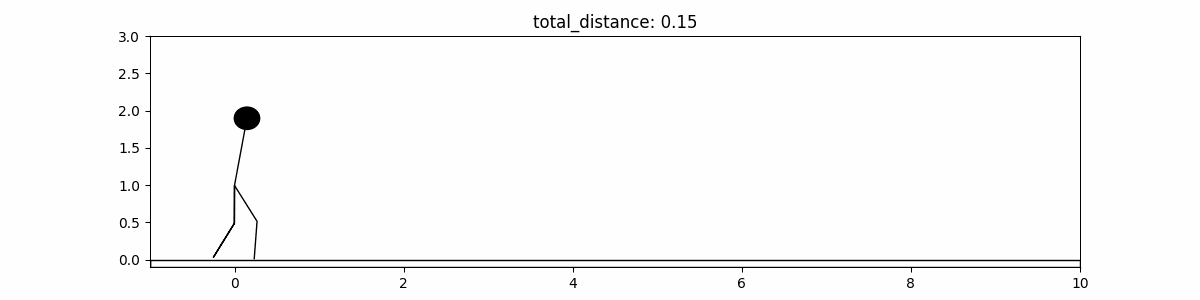

In [6]:
# Simulate the optimized plan from Simulated Annealing
data_sa, total_distance_sa = sim(best_plan_sa)
print("Simulated Annealing - Total Distance (Optimized):", total_distance_sa)

# Create the GIF for Simulated Annealing
frames_sa = [plot_samples_normal(data_sa, j) for j in range(len(data_sa))]
gif.save(frames_sa, "simulated_annealing.gif", duration=40)
Image(filename="simulated_annealing.gif")

In [7]:
# Evolutionary Algorithm
def optimize_evolutionary(sim, population_size=20, generations=50, mutation_rate=0.1):
    """
    Optimize the control plan using Evolutionary Algorithms.

    Args:
    - sim: Simulation function.
    - population_size: Number of plans in the population.
    - generations: Number of iterations.
    - mutation_rate: Probability of mutating a plan.

    Returns:
    - best_plan: Optimized control plan.
    - best_distance: Maximum distance achieved.
    """
    def clamp(value):
        return max(-1, min(1, value))

    def mutate(plan, mutation_rate):
        return [clamp(x + random.uniform(-0.1, 0.1) if random.random() < mutation_rate else x) for x in plan]

    def crossover(plan1, plan2):
        split = random.randint(1, len(plan1) - 1)
        return plan1[:split] + plan2[split:]

    # Initialize a random population
    population = [[random.uniform(-1, 1) for _ in range(40)] for _ in range(population_size)]
    fitness = [sim(plan)[1] for plan in population]

    for generation in range(generations):
        # Select the top 50% of the population
        sorted_indices = np.argsort(fitness)[::-1]
        top_population = [population[i] for i in sorted_indices[:population_size // 2]]

        # Generate offspring through crossover
        offspring = []
        for _ in range(population_size // 2):
            parents = random.sample(top_population, 2)
            child = crossover(parents[0], parents[1])
            offspring.append(child)

        # Mutate offspring
        mutated_offspring = [mutate(plan, mutation_rate) for plan in offspring]

        # Combine top performers and offspring
        population = top_population + mutated_offspring
        fitness = [sim(plan)[1] for plan in population]

        # Debugging output
        print(f"Generation {generation}: Best Distance = {max(fitness):.2f}")

    # Return the best plan and its corresponding distance
    best_index = np.argmax(fitness)
    return population[best_index], fitness[best_index]

Generation 0: Best Distance = 2.15
Generation 1: Best Distance = 2.15
Generation 2: Best Distance = 2.36
Generation 3: Best Distance = 2.36
Generation 4: Best Distance = 2.36
Generation 5: Best Distance = 2.36
Generation 6: Best Distance = 2.36
Generation 7: Best Distance = 2.45
Generation 8: Best Distance = 2.59
Generation 9: Best Distance = 2.59
Generation 10: Best Distance = 2.64
Generation 11: Best Distance = 2.64
Generation 12: Best Distance = 2.64
Generation 13: Best Distance = 2.64
Generation 14: Best Distance = 2.64
Generation 15: Best Distance = 2.64
Generation 16: Best Distance = 2.64
Generation 17: Best Distance = 2.64
Generation 18: Best Distance = 2.64
Generation 19: Best Distance = 2.64
Generation 20: Best Distance = 2.64
Generation 21: Best Distance = 2.64
Generation 22: Best Distance = 2.64
Generation 23: Best Distance = 2.65
Generation 24: Best Distance = 2.65
Generation 25: Best Distance = 2.65
Generation 26: Best Distance = 2.66
Generation 27: Best Distance = 2.72
Ge

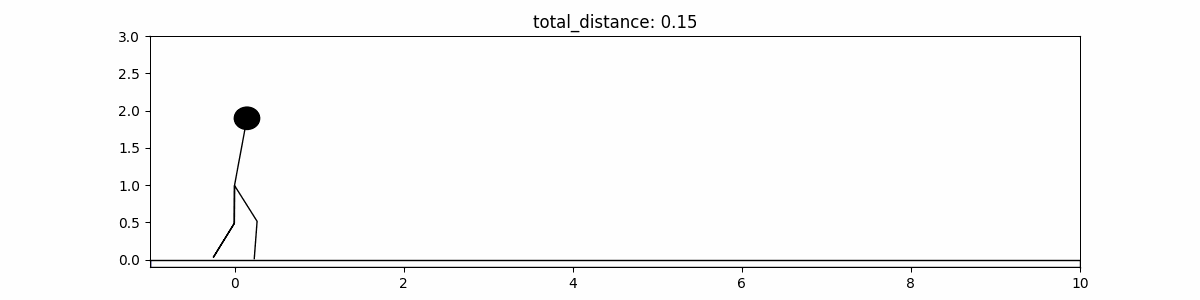

In [8]:

initial_plan = [random.uniform(-1, 1) for _ in range(40)]

best_plan_ea, best_distance_ea = optimize_evolutionary(sim)
print("Evolutionary Algorithm - Best Plan:", best_plan_ea)
print("Evolutionary Algorithm - Best Distance:", best_distance_ea)

#Simulating Evolutionary Algorithm
data_ea, _ = sim(best_plan_ea)

# Create GIFs
frames_ea = [plot_samples_normal(data_ea, j) for j in range(len(data_ea))]
gif.save(frames_ea, "evolutionary_algorithm.gif", duration=40)
Image(filename="evolutionary_algorithm.gif")
